# Autovalores Repetidos

O último caso é quando a matriz tem um **autovalor repetido**. Para uma matriz $2\times2$, isso acontece quando $\Delta=(\operatorname{tr}A)^2-4\det A=0$, e então $\lambda=\tfrac12\operatorname{tr}A$ é raiz dupla. Como vimos na aula de autovalores, há duas possibilidades:

* o autovalor duplo tem **dois** autovetores independentes — e então não há problema nenhum;
* o autovalor duplo tem **um só** autovetor (a matriz é chamada **defeituosa**) — e então falta uma solução.

O segundo caso é o análogo exato das raízes repetidas na segunda ordem, e a solução também vai envolver um fator $t$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

def retrato(A, ax, lim=3, titulo=None, autovetores=True):
    # Desenha o retrato de fase de x' = A x no quadrado [-lim, lim]^2
    A = np.array(A, dtype=float)
    s = np.linspace(-lim, lim, 40)
    X, Y = np.meshgrid(s, s)
    U = A[0, 0]*X + A[0, 1]*Y
    V = A[1, 0]*X + A[1, 1]*Y
    ax.streamplot(X, Y, U, V, color='0.55', density=1.1, linewidth=0.8, arrowsize=1)
    if autovetores:
        lam, vec = np.linalg.eig(A)
        if np.all(np.abs(lam.imag) < 1e-12):
            pares = list(zip(lam.real, vec.T.real))
            if abs(lam[0] - lam[1]) < 1e-6:
                pares = pares[:1]
            for l, v in pares:
                ax.plot([-3*lim*v[0], 3*lim*v[0]], [-3*lim*v[1], 3*lim*v[1]],
                        '--', linewidth=2, label=fr'$\lambda={l:.3g}$')
            ax.legend(loc='lower right', fontsize=8)
    ax.plot(0, 0, 'ko', markersize=5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    if titulo:
        ax.set_title(titulo)

def trajetoria(A, x0, T, ax, cor='b'):
    # Integra x' = A x a partir de x0 e desenha a trajetória
    A = np.array(A, dtype=float)
    sol = solve_ivp(lambda t, x: A @ x, (0, T), x0, max_step=T/500)
    ax.plot(sol.y[0], sol.y[1], color=cor, linewidth=2.5)
    ax.plot(x0[0], x0[1], 'o', color=cor, markersize=7)
    return sol

## Primeiro caso: dois autovetores

Se $\lambda$ é duplo e tem dois autovetores independentes $\mathbf{v}^{(1)},\mathbf{v}^{(2)}$, a receita de sempre funciona: $\mathbf{x}(t)=c_1\mathbf{v}^{(1)}e^{\lambda t}+c_2\mathbf{v}^{(2)}e^{\lambda t}$. Para uma matriz $2\times2$, isso só acontece se $A=\lambda I$ (múltiplo da identidade), e então **todo** vetor é autovetor. Por exemplo, para $A=\begin{pmatrix} -1 & 0\\ 0 & -1\end{pmatrix}$, o sistema é $x_1'=-x_1,\ x_2'=-x_2$, com solução $\mathbf{x}(t)=e^{-t}\begin{pmatrix} c_1\\ c_2\end{pmatrix}$: todas as soluções vão em linha reta para a origem. Esse retrato é chamado de **nó próprio** (ou **estrela**). (Já vimos, na aula de autovalores reais, um exemplo $3\times3$ desse tipo, em que o autovalor duplo também tinha dois autovetores.)

## Segundo caso: um só autovetor

### Exemplo 1

Encontre a solução geral de

$$
\mathbf{x}' = \begin{pmatrix} 1 & -1\\ 1 & 3\end{pmatrix}\mathbf{x}.
$$

**Autovalores:** $\operatorname{tr}A=4$ e $\det A=3+1=4$, então $\lambda^2-4\lambda+4=(\lambda-2)^2=0$ e $\lambda=2$ é duplo.

**Autovetores:** $(A-2I)\mathbf{v}=\begin{pmatrix} -1 & -1\\ 1 & 1\end{pmatrix}\mathbf{v}=\mathbf{0}$ dá apenas $v_1+v_2=0$, ou seja, só a direção $\mathbf{v}=\begin{pmatrix} 1\\ -1\end{pmatrix}$. Temos **uma** solução, $\mathbf{x}^{(1)}(t)=\begin{pmatrix} 1\\ -1\end{pmatrix}e^{2t}$, e precisamos de outra.

**Procurando a segunda solução.** Inspirados na segunda ordem, onde a segunda solução era $te^{rt}$, poderíamos tentar $\mathbf{x}=te^{\lambda t}\mathbf{v}$. Mas isso não funciona (derivando sobra um termo $e^{\lambda t}\mathbf{v}$ que não se cancela). A correção é acrescentar mais um termo:

$$
\mathbf{x}(t) = te^{\lambda t}\mathbf{v} + e^{\lambda t}\mathbf{w},
$$

com $\mathbf{w}$ um vetor constante a determinar. Derivando,

$$
\mathbf{x}' = e^{\lambda t}\mathbf{v} + \lambda te^{\lambda t}\mathbf{v} + \lambda e^{\lambda t}\mathbf{w},
$$

e, do outro lado, usando $A\mathbf{v}=\lambda\mathbf{v}$,

$$
A\mathbf{x} = te^{\lambda t}A\mathbf{v} + e^{\lambda t}A\mathbf{w} = \lambda te^{\lambda t}\mathbf{v} + e^{\lambda t}A\mathbf{w}.
$$

Igualando e cancelando $\lambda te^{\lambda t}\mathbf{v}$ e $e^{\lambda t}$, sobra $\mathbf{v}+\lambda\mathbf{w}=A\mathbf{w}$, ou seja,

$$
(A-\lambda I)\,\mathbf{w} = \mathbf{v}.
$$

Um sistema linear **não homogêneo** para $\mathbf{w}$, com a mesma matriz singular $A-\lambda I$ e o autovetor do lado direito. O vetor $\mathbf{w}$ é chamado de **autovetor generalizado**.

Voltando ao exemplo: $(A-2I)\mathbf{w}=\begin{pmatrix} -1 & -1\\ 1 & 1\end{pmatrix}\begin{pmatrix} w_1\\ w_2\end{pmatrix}=\begin{pmatrix} 1\\ -1\end{pmatrix}$ dá a única condição $-w_1-w_2=1$. Qualquer solução serve; escolhendo $w_1=0$, temos $\mathbf{w}=\begin{pmatrix} 0\\ -1\end{pmatrix}$. (Escolhas diferentes de $\mathbf{w}$ diferem por um múltiplo de $\mathbf{v}$, que só muda a constante $c_1$.)

**Solução geral:**

$$
\mathbf{x}(t) = c_1\begin{pmatrix} 1\\ -1\end{pmatrix}e^{2t} + c_2\left[\begin{pmatrix} 1\\ -1\end{pmatrix}te^{2t} + \begin{pmatrix} 0\\ -1\end{pmatrix}e^{2t}\right].
$$

(A - 2I) w = Matrix([[1, -1]])  (deve ser v)
segunda solução é solução? Matrix([[0, 0]])
W(0) = -1


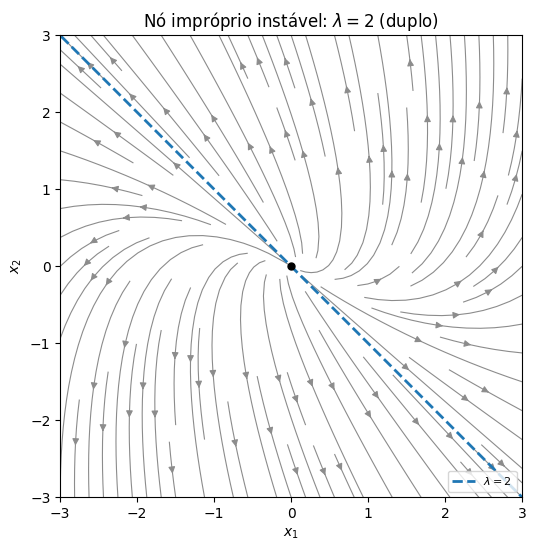

In [2]:
t, c1, c2 = sp.symbols('t c1 c2')
A = sp.Matrix([[1, -1], [1, 3]])
v = sp.Matrix([1, -1]); w = sp.Matrix([0, -1])
print("(A - 2I) w =", ((A - 2*sp.eye(2))*w).T, " (deve ser v)")
x2 = v*t*sp.exp(2*t) + w*sp.exp(2*t)
print("segunda solução é solução?", sp.simplify(x2.diff(t) - A*x2).T)
print("W(0) =", sp.Matrix.hstack(v, w).det())

fig, ax = plt.subplots(figsize=(6, 6))
retrato(np.array(A, dtype=float), ax, lim=3, titulo=r"Nó impróprio instável: $\lambda=2$ (duplo)")
plt.show()

O retrato de fase tem uma única reta invariante (a do autovetor), e todas as trajetórias saem da origem **tangentes a ela**, curvando-se para acompanhar a mesma direção quando se afastam. É o **nó impróprio** (ou **nó degenerado**), que aqui é **instável**, pois $\lambda=2>0$. Ele é o caso de transição entre um nó (dois autovetores reais) e um foco (autovalores complexos): as trajetórias "quase giram", mas não chegam a dar a volta.

### Exemplo 2: o amortecimento crítico

Encontre a solução geral do oscilador criticamente amortecido $x''+2x'+x=0$, escrito como sistema:

$$
\mathbf{x}' = \begin{pmatrix} 0 & 1\\ -1 & -2\end{pmatrix}\mathbf{x}.
$$

Aqui $\operatorname{tr}A=-2$, $\det A=1$ e $\Delta=4-4=0$: $\lambda=-1$ é duplo, como esperado para o amortecimento crítico. Os autovetores: $(A+I)\mathbf{v}=\begin{pmatrix} 1 & 1\\ -1 & -1\end{pmatrix}\mathbf{v}=\mathbf{0}$ dá só $\mathbf{v}=\begin{pmatrix} 1\\ -1\end{pmatrix}$. O autovetor generalizado: $(A+I)\mathbf{w}=\mathbf{v}$ dá $w_1+w_2=1$, e escolhemos $\mathbf{w}=\begin{pmatrix} 1\\ 0\end{pmatrix}$. Então

$$
\mathbf{x}(t) = c_1\begin{pmatrix} 1\\ -1\end{pmatrix}e^{-t} + c_2\left[\begin{pmatrix} 1\\ -1\end{pmatrix}te^{-t} + \begin{pmatrix} 1\\ 0\end{pmatrix}e^{-t}\right].
$$

A primeira componente é $x(t)=(c_1+c_2)e^{-t}+c_2te^{-t}$: exatamente a forma $(C_1+C_2t)e^{-t}$ que encontramos para raízes repetidas na segunda ordem. O fator $t$ da segunda ordem e o autovetor generalizado do sistema são a mesma coisa, vista de dois ângulos.

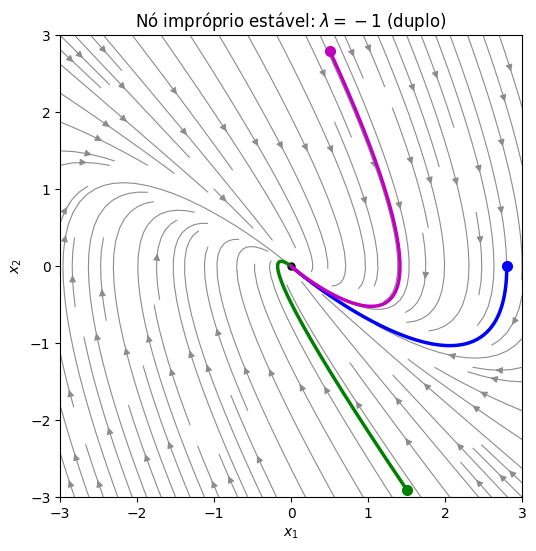

In [3]:
A = np.array([[0, 1], [-1, -2]])
fig, ax = plt.subplots(figsize=(6, 6))
retrato(A, ax, lim=3, titulo=r"Nó impróprio estável: $\lambda=-1$ (duplo)")
for x0, cor in [([2.8, 0], 'b'), ([1.5, -2.9], 'g'), ([0.5, 2.8], 'm')]:
    trajetoria(A, x0, 12, ax, cor=cor)
plt.show()

Agora $\lambda=-1<0$: todas as trajetórias vão para a origem, chegando tangentes ao autovetor. É um **nó impróprio estável**, e a origem é assintoticamente estável. Repare na trajetória verde, que começa com a massa sendo lançada com velocidade forte em direção ao equilíbrio: ela cruza o eixo vertical ($x=0$) uma vez antes de chegar à origem (a massa passa uma vez pela posição de equilíbrio). Mas nenhuma trajetória dá a volta na origem — esse é o comportamento do amortecimento crítico.

Em sistemas $3\times3$, um autovalor pode aparecer até três vezes, e então pode ser preciso um termo com $t^2$; não vamos tratar esse caso.

## Resumo: autovalor repetido ($2\times2$)

Se $\lambda$ é autovalor duplo:

* **com dois autovetores** ($A=\lambda I$): $\mathbf{x}(t)=e^{\lambda t}\mathbf{c}$, retrato de **nó próprio** (estrela);
* **com um só autovetor** $\mathbf{v}$: encontre $\mathbf{w}$ com $(A-\lambda I)\mathbf{w}=\mathbf{v}$, e
$$
\mathbf{x}(t) = c_1\mathbf{v}e^{\lambda t} + c_2\big(\mathbf{v}te^{\lambda t} + \mathbf{w}e^{\lambda t}\big),
$$
com retrato de **nó impróprio**.

Em ambos os casos, a estabilidade depende só do sinal de $\lambda$: $\lambda<0$ assintoticamente estável, $\lambda>0$ instável. (O fator $t$ não muda isso: $te^{\lambda t}\to0$ quando $\lambda<0$, porque a exponencial "vence" o $t$.)

**Ligação com traço e determinante.** Autovalor repetido acontece exatamente quando $(\operatorname{tr}A)^2=4\det A$, e então $\lambda=\tfrac12\operatorname{tr}A$: o **sinal do traço** decide a estabilidade.